In [10]:
from modules import rrt,attmil,mhim
import torch
import seaborn as sns
import numpy as np

from vis_utils import *
import h5py
from xml.dom.minidom import parse
import xml.dom.minidom
from openTSNE import TSNE
from sklearn.manifold import TSNE as ttsne
from shapely.geometry import Polygon
from copy import deepcopy
from download import find_model
from models import DiT_models

## Function

In [3]:
def read_annotation(anno_file,return_type=False):
    anno_tumor = []
    anno_normal = []
    anno_type = set()
    # 使用minidom解析器打开 XML 文档

    DOMTree = xml.dom.minidom.parse(anno_file)
    print(DOMTree)

    annotations = DOMTree.documentElement.getElementsByTagName('Annotations')[0].getElementsByTagName('Annotation')

    for i in range(len(annotations)):

        anno_type.add(annotations[i].getAttribute('PartOfGroup'))

        if annotations[i].getAttribute('PartOfGroup') == 'Exclusion':
            coordinates = annotations[i].getElementsByTagName('Coordinates')
            _tmp = []
            for node in coordinates[0].childNodes:
                if type(node) == xml.dom.minidom.Element:
                    _tmp.append([int(float(node.getAttribute("X"))),int(float(node.getAttribute("Y")))])

            anno_normal.append(_tmp)
        elif annotations[i].getAttribute('PartOfGroup') != 'None':
            coordinates = annotations[i].getElementsByTagName('Coordinates')
            _tmp = []
            for node in coordinates[0].childNodes:
                if type(node) == xml.dom.minidom.Element:
                    _tmp.append([int(float(node.getAttribute("X"))),int(float(node.getAttribute("Y")))])

            anno_tumor.append(_tmp)
    if return_type:
        return anno_tumor,anno_normal,anno_type
    else:
        return anno_tumor,anno_normal

In [36]:
def normalize_rgb(r, g, b):
    return r / 255.0, g / 255.0, b / 255.0

c_0 = normalize_rgb(152, 177, 217)
c_1 = normalize_rgb(234, 98, 122)  # 例如，红色
c_2 = normalize_rgb(249, 180, 116) 

In [4]:
def get_label(coords,anno_file,_l=None):
    
    if anno_file is None:
       
        return None
    label = []

    annos_tumor,annos_normal = read_annotation(anno_file)

    annos_tumor_polygon = [ Polygon(_anno) for _anno in annos_tumor ]
    annos_normal_polygon = [ Polygon(_anno) for _anno in annos_normal ]
    annos_tumor_in_normal_idx = []

    # 有一部分tumor是在exclusion里面，需要区别出这些tumor出来
    for idx,_anno in enumerate(annos_tumor_polygon):
        for _anno_1 in annos_normal_polygon:
            if _anno.covered_by(_anno_1):
                annos_tumor_in_normal_idx.append(idx)
    
    for coord in coords:
        _patch = Polygon([coord,[coord[0]+512,coord[1]],[coord[0]+512,coord[1]+512],[coord[0],coord[1]+512]])
        _flag = 0
        _flag_always = 0
        for idx,_anno in enumerate(annos_tumor_polygon):
            if _patch.intersects(_anno):
                _flag = 1
                if idx in annos_tumor_in_normal_idx:
                    _flag_always = 1
        if not _flag_always:
            for _anno_1 in annos_normal_polygon:
                if _patch.intersects(_anno_1):
                    _flag = 0
                
        if _flag:
            #label.append(1)
            if _l is not None:
                label.append(0)
            else:
                label.append(1)
        else:
            label.append(0)
    label = np.array(label)

    if _l is not None:
        #label[np.array(label == 0) * np.array(_l > 0)] = 1
        label[np.array(_l > 0)] = 1
        
    return label

In [66]:
# def plot(
#     x,
#     y,
#     ax=None,
#     title=None,
#     draw_legend=True,
#     draw_centers=False,
#     draw_cluster_labels=False,
#     colors=None,
#     legend_kwargs=None,
#     label_order=None,
#     **kwargs
# ):
#     import matplotlib

#     if ax is None:
#         _, ax = matplotlib.pyplot.subplots(figsize=(8, 8))

#     if title is not None:
#         ax.set_title(title)

#     #plot_params = {"alpha": kwargs.get("alpha", 0.6), "s": kwargs.get("s", 1)}
#     plot_params = {"alpha": kwargs.get("alpha", 0.8)}

#     # Create main plot
#     if label_order is not None:
#         assert all(np.isin(np.unique(y), label_order))
#         classes = [l for l in label_order if l in np.unique(y)]
#     else:
#         classes = np.unique(y)
#     if colors is None:
#         default_colors = matplotlib.rcParams["axes.prop_cycle"]
#         colors = {k: v["color"] for k, v in zip(classes, default_colors())}

#     point_colors = list(map(colors.get, y))

#     size = deepcopy(y)
#     point_size = deepcopy(y)
#     point_size[size != 1] = 1
#     point_size[size == 1] = 20 #50
#     point_size[size == 2] = 1
    

#     fig=ax.scatter(x[:, 0], x[:, 1], c=point_colors, rasterized=True, s=point_size,**plot_params)
    
#     # Plot mediods
#     if draw_centers:
#         centers = []
#         for yi in classes:
#             mask = yi == y
#             centers.append(np.median(x[mask, :2], axis=0))
#         centers = np.array(centers)

#         center_colors = list(map(colors.get, classes))
#         ax.scatter(
#             centers[:, 0], centers[:, 1], c=center_colors, s=48, alpha=1, edgecolor="k"
#         )

#         # Draw mediod labels
#         if draw_cluster_labels:
#             for idx, label in enumerate(classes):
#                 ax.text(
#                     centers[idx, 0],
#                     centers[idx, 1] + 2.2,
#                     label+': '+str(len(x)),
#                     fontsize=kwargs.get("fontsize", 6),
#                     horizontalalignment="center",
#                 )

#     # Hide ticks and axis
#     ax.set_xticks([]), ax.set_yticks([]), ax.axis("off")

#     if draw_legend:
#         legend_handles = [
#             matplotlib.lines.Line2D(
#                 [],
#                 [],
#                 marker="s",
#                 color="w",
#                 markerfacecolor=colors[yi],
#                 ms=10,
#                 alpha=1,
#                 linewidth=0,
#                 label=str(yi)+': '+str(len(y[y ==yi])),
#                 markeredgecolor="k",
#             )
#             for yi in classes
#         ]
#         legend_kwargs_ = dict(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, )
#         if legend_kwargs is not None:
#             legend_kwargs_.update(legend_kwargs)
#         ax.legend(handles=legend_handles, **legend_kwargs_)
    
#     return fig


def plot(
    x,
    y,
    ax=None,
    title=None,
    draw_legend=True,
    draw_centers=False,
    draw_cluster_labels=False,
    colors=None,
    legend_kwargs=None,
    label_order=None,
    **kwargs
):
    import matplotlib.pyplot as plt
    from copy import deepcopy
    import numpy as np

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))

    if title is not None:
        ax.set_title(title)

    plot_params = {"alpha": kwargs.get("alpha", 0.8)}

    if label_order is not None:
        assert all(np.isin(np.unique(y), label_order))
        classes = [l for l in label_order if l in np.unique(y)]
    else:
        classes = np.unique(y)

    # Set colors for each label
    if colors is None:
        colors = {0: c_0, 1: c_1, 2: c_2, 3: 'white'}

    point_colors = list(map(colors.get, y))

    size = deepcopy(y)
    point_size = deepcopy(y)
    point_size[size != 1] = 2
    point_size[size == 1] = 10
    point_size[size == 2] = 2
    point_size[size == 3] = 5

    fig = ax.scatter(x[:, 0], x[:, 1], c=point_colors, rasterized=True, s=point_size, **plot_params)

    if draw_centers:
        centers = []
        for yi in classes:
            mask = yi == y
            centers.append(np.median(x[mask, :2], axis=0))
        centers = np.array(centers)

        center_colors = list(map(colors.get, classes))
        ax.scatter(
            centers[:, 0], centers[:, 1], c=center_colors, s=48, alpha=1, edgecolor="k"
        )

        if draw_cluster_labels:
            for idx, label in enumerate(classes):
                ax.text(
                    centers[idx, 0],
                    centers[idx, 1] + 2.2,
                    label + ': ' + str(len(x[y == label])),
                    fontsize=kwargs.get("fontsize", 6),
                    horizontalalignment="center",
                )

    ax.set_xticks([]), ax.set_yticks([]), ax.axis("off")

    if draw_legend:
        legend_handles = [
            plt.Line2D(
                [],
                [],
                marker="s",
                color="w",
                markerfacecolor=colors[yi],
                ms=10,
                alpha=1,
                linewidth=0,
                label=str(yi) + ': ' + str(len(y[y == yi])),
                markeredgecolor="k",
            )
            for yi in classes
        ]
        legend_kwargs_ = dict(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
        if legend_kwargs is not None:
            legend_kwargs_.update(legend_kwargs)
        ax.legend(handles=legend_handles, **legend_kwargs_)

    return fig


In [83]:
def tsne(feat,Dit,coords=None,anno_file=None,_l=None,mask=None,**kwargs):
    try:
        label = get_label(coords,anno_file,_l)
        print("ones_count")
        ones_count = len(label) 
        print(ones_count)
    except:
        print("wrong")
        label = None
    #label = get_label(coords,anno_file,_l)
    print(label)
    feat_mhim=feat.unsqueeze(0)
# 载入筛选模型
    f_after_chose,label_after_chose,blabel=mask.forward_tsne(feat,label,Dit)
    b_faker=blabel.copy()
    for i in range(len(label)):
        if label[i] == 1 and blabel[i] != 1:
            b_faker[i] = 1
    b_stay = np.where(blabel == 2, label, 2)


    b_random = np.copy(label)
    num_random_elements = int(len(label) * 0.2)
    random_indices = np.random.choice(len(label), num_random_elements, replace=False)
    b_random[random_indices] = 2


    print("embeding_start")
    #embedding = TSNE(n_jobs=8).fit(feat)
    tsne = ttsne(n_components=2, perplexity=30, learning_rate=200, random_state=0)
    embedding = tsne.fit_transform(feat)
    f_after_chose = f_after_chose.cpu()
    #embedding = tsne.fit_transform(f_after_chose)
    print("embeding_finsihed")
    print("label_after_chose")
    print(label_after_chose)
    print(len(label_after_chose))
    print(label)
    print(len(label))
    y = label if label is not None else np.array([1 for i in range(len(embedding))])
    y = label_after_chose if label_after_chose is not None else np.array([1 for i in range(len(embedding))])
    y = blabel if blabel is not None else np.array([1 for i in range(len(embedding))])
    # y = b_faker if b_faker is not None else np.array([1 for i in range(len(embedding))])
    y = b_stay if b_stay is not None else np.array([1 for i in range(len(embedding))])
    #y = b_random if b_random is not None else np.array([1 for i in range(len(embedding))])
    return plot(embedding,y,**kwargs)

## Init

In [1]:
# _rrt = rrt.RRTMIL(pos='none',attn='rrt',ic=True,n_layers=2,da_act='tanh',trans_conv=True,moe_fl_enable=False,moe_mlp=False,input_dim=1024,moe_mask_diag=False,minmax_weight=True,moe_k=1,all_shortcut=True,l2_n_heads=8,l1_shortcut=True,conv_k=15).eval().requires_grad_(False)

# cpt = torch.load('/data/tangwenhao/output/mil/mil_clam_c16_other/rrt_attn_convk15_N1SCsmoe_l2mm/fold_1_model_best_auc.pt')
# _rrt.load_state_dict(cpt['model'],strict=False)


#diff
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

#diffSim
from modules.diffmil import fastDAttentionWithDiffEnd as diffSim
Dit= (DiT_models["DiT-XL/2"](input_size=32)).to(device)
ckpt_path = "/home/shihuazhan/DiT/DiT/pretrained_models/DiT-XL-2-256x256.pt"
# ckpt_path = "/data/zhangxiaoxian/output/pretrained_models/DiT-XL-2-256x256.pt"
state_dict = find_model(ckpt_path)
Dit.load_state_dict(state_dict)
Dit.eval()

NameError: name 'torch' is not defined

In [6]:
# MHIM
from modules.mhim import MHIM
mask = MHIM(da_act='relu',baseline='selfattn').eval()
mask.requires_grad_(False)

mask_cpt = torch.load('/data/shihuazhan/output_wsi/mhim/mhim.pt',map_location='cpu')

mask.load_state_dict(mask_cpt['model'])

<All keys matched successfully>

In [ ]:
_ntrans = rrt.RRTMIL(pos='none',attn='ntrans',n_layers=1,da_act='tanh',ic=True,all_shortcut=False).eval().requires_grad_(False)

cpt = torch.load('/data/tangwenhao/output/mil/mil_clam_c16_other/ntrans_attn/fold_1_model_best_auc.pt')
_ntrans.load_state_dict(cpt['model'],strict=False)

In [50]:
# _abmil = attmil.DAttention(2,dropout=True,act='relu',test=False,input_dim=1024).eval().requires_grad_(False)

# cpt = torch.load('/home/tangwenhao/code/mil/vis/attn_seed2021_fold_1_model_best_auc.pt')
# _abmil.load_state_dict(cpt['model'],strict=False)

# _abmil_plip = attmil.DAttention(2,dropout=True,act='relu',test=False,input_dim=512).eval().requires_grad_(False)

# cpt = torch.load('/data/tangwenhao/output/mil/mil_clam_c16_other/plip_abmil/fold_1_model_best_auc.pt')
# _abmil_plip.load_state_dict(cpt['model'],strict=False)

mask = diffSim(out_dim=2,k_ratio=0.2,t_steps=2,ifrand=2,ifTrain=1,a_ratio=1.0,adapter_ratio=0.1).eval()
mask.requires_grad_(False)

#mask_cpt = torch.load('/data/shihuazhan/output_wsi/mil_shz/slowcall_twh_mean_0.5_samex1_x2_train_emd_adapter0.1/fold_3_model_best_auc.pt',map_location='cpu')
mask_cpt = torch.load('/data/shihuazhan/output_wsi/mil_shz/fastcall_twh_mean_0.5_samex1_x2_train_emd_adapter1.0/fold_3_model_best_auc.pt',map_location='cpu')

mask.load_state_dict(mask_cpt['model'])

<All keys matched successfully>

In [ ]:
_f = 'TCGA-33-4532-01Z-00-DX1.32ab8c26-7cdc-4e55-8c70-5a35d83f81a2'
feat = torch.load('/nas/zhangxiaoxian/tcga/zft/pt_files/'+_f+'.pt')
coords = None
print(feat.size())
label = None

In [90]:
_f = 'tumor_025' #012 013 014
#plip_feat = torch.load('/data/tangwenhao/c16_clam_bio_seg/plip/pt/'+_f+'.pt')
patch = h5py.File('/data/zhangxiaoxian/c16_clam_bio_seg/h5/'+_f+'.h5',"r")# /home/tangwenhao/dataset/mil/c16_clam_bio_seg/h5/

feat = torch.Tensor(patch['features'])
coords = patch['coords']
print(feat.size())
#label = get_label(coords,"/home/tangwenhao/dataset/mil/c16_clam_bio_seg/vis/c_16_lesion_annotation/"+_f+".xml")
#print(len(label[label==0]),len(label[label==1]))




torch.Size([7179, 1024])


## Attention Distributions

### Ntrans

In [ ]:
with torch.no_grad():
    x,attns = _ntrans(feat.unsqueeze(0),return_attn=True)
print(torch.nn.functional.softmax(x,dim=-1))

_a = attns[0]
_a,_ = torch.sort(_a,descending=True)
sns.scatterplot(x=np.array(list(range(_a.size(0)))),y=_a,s=100,alpha=0.6)

### ABMIL w/ PLIP

In [ ]:
with torch.no_grad():
    x,attns = _abmil_plip.forward(plip_feat.unsqueeze(0),return_attn=True)
print(torch.nn.functional.softmax(x,dim=-1))

_a = attns[0]
_a,_ = torch.sort(_a,descending=True)
sns.scatterplot(x=np.array(list(range(_a.size(0)))),y=_a,s=100,alpha=0.6)

### ABMIL w/ R50

In [ ]:
with torch.no_grad():
    x,attns = _abmil.forward(feat.unsqueeze(0),return_attn=True)
print(torch.nn.functional.softmax(x,dim=-1))

_a = attns[0]
_a,_ = torch.sort(_a,descending=True)
sns.scatterplot(x=np.array(list(range(_a.size(0)))),y=_a,s=100,alpha=0.6)

### RRT-MIL

In [ ]:
with torch.no_grad():
    x,attns,trans_attns = _rrt.forward(feat.unsqueeze(0),return_attn=True,return_trans_attn=True)
print(torch.nn.functional.softmax(x,dim=-1))

#_a = torch.nn.functional.softmax(attns[0])
_a = attns[0]
_a,_ = torch.sort(_a,descending=True)
sns.scatterplot(x=np.array(list(range(_a.size(0)))),y=_a,s=100,alpha=0.6)

## Feature Vis

### PLIP Features

In [ ]:
feat_vis = tsne(torch.tensor(plip_feat).squeeze(0),coords,"/data2/shihuazhan/dataset/c16_test_anno/test_annotations"+_f+".xml",draw_legend=False)
feat_vis.get_figure().savefig('./vis_figure/ori_plip.png',dpi=300,bbox_inches='tight')

### R50 Features

/tmp/ipykernel_518264/1606400453.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  feat_vis = tsne(torch.tensor(feat).squeeze(0),Dit,coords,"/data2/shihuazhan/dataset/c16_test_anno/train_annotations/"+_f+".xml",mask=mask,draw_legend=False)   #/home/tangwenhao/dataset/mil/c16_clam_bio_seg/vis/c_16_lesion_annotation/


ones_count
7179
[0 0 0 ... 0 0 0]
embeding_start
embeding_finsihed
label_after_chose
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

FileNotFoundError: [Errno 2] No such file or directory: './vis_figure/ori.png'

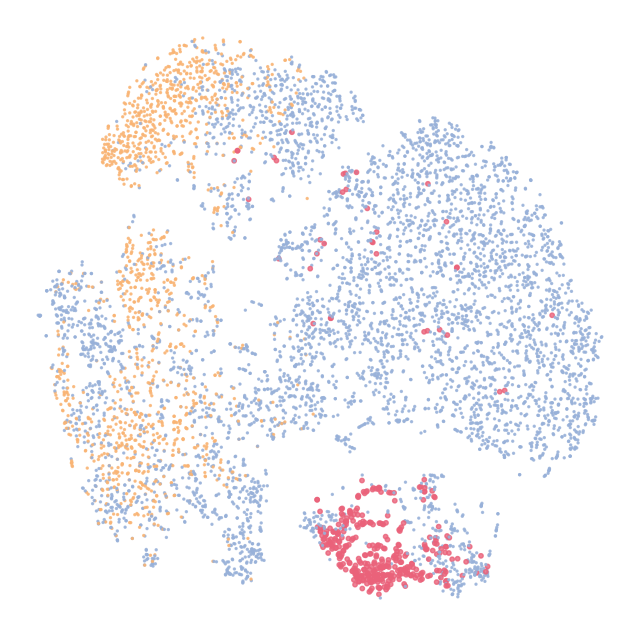

In [96]:
feat_vis = tsne(torch.tensor(feat).squeeze(0),Dit,coords,"/data2/shihuazhan/dataset/c16_test_anno/train_annotations/"+_f+".xml",mask=mask,draw_legend=False)   #/home/tangwenhao/dataset/mil/c16_clam_bio_seg/vis/c_16_lesion_annotation/
print("hi") #/data2/shihuazhan/dataset/c16_test_anno/train_annotations/tumor_111.xml
feat_vis.get_figure().savefig('./vis_figure/ori.png',dpi=300,bbox_inches='tight')

### Features After FC in ABMIL

In [ ]:
feat_fc = tsne(_abmil.feature(torch.tensor(feat).squeeze(0)),coords,"/home/tangwenhao/dataset/mil/c16_clam_bio_seg/vis/c_16_lesion_annotation/"+_f+".xml",draw_legend=False)
feat_fc.get_figure().savefig('./vis_figure/fc.png',dpi=300,bbox_inches='tight')

### Features After Ntrans

In [ ]:
feat_ntrans = _ntrans.online_encoder(_ntrans.dp(_ntrans.patch_to_emb(torch.tensor(feat).squeeze(0))),no_pool=True)
feat_ntrans = tsne(feat_ntrans,coords,"/home/tangwenhao/dataset/mil/c16_clam_bio_seg/vis/c_16_lesion_annotation/"+_f+".xml",draw_legend=False)
feat_ntrans.get_figure().savefig('./vis_figure/ntrans.png',dpi=300,bbox_inches='tight')

### Features After RRT-MIL

In [ ]:
feat_rrt = _rrt.online_encoder(_rrt.dp(_rrt.patch_to_emb(torch.tensor(feat).squeeze(0))),no_pool=True)
feat_rrt = tsne(feat_rrt,coords,"/home/tangwenhao/dataset/mil/c16_clam_bio_seg/vis/c_16_lesion_annotation/"+_f+".xml",draw_legend=False)
feat_rrt.get_figure().savefig('./vis_figure/rrt_as.png',dpi=300,bbox_inches='tight')

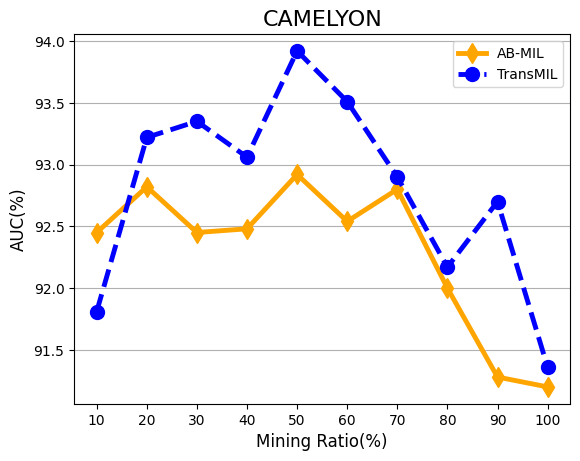

In [ ]:
import matplotlib.pyplot as plt

# # 数据
# x = [3, 9, 15, 21]
# y = [97.5, 98, 97.8, 98.2]

# # 创建图形和轴
# fig, ax = plt.subplots()

# # 绘制线条
# ax.plot(x, y, marker='o', color='orange', linewidth=2)

# # 设置标签和标题
# ax.set_xlabel('(a) Diagnosis (C16)', fontsize=12)
# ax.set_ylabel('AUC', fontsize=12)

# # 设置刻度
# ax.set_xticks(x)
# ax.set_yticks([96, 96.5, 97, 97.5, 98, 98.5, 99])

# # 添加网格线
# ax.yaxis.grid(True)

# # 显示图形
# plt.show()

import matplotlib.pyplot as plt

# 数据
x = [0.1, 0.2, 0.3, 0.4,0.5,0.6,0.7,0.8,0.9,1.0]
#x = [10, 20, 30, 40,50,60,70,80,90,100]
y1 = [92.45, 92.82, 92.45, 92.48, 92.92, 92.54, 92.8, 92.0, 91.28, 91.20]  # 第一条线的值  AB-mil 在call上不同挖掘比的AUC 少1，10
#y2 = [-, 89.54, 90.2, 90.42, 90.2, 89.09, 89.31, 88.75, 87.97, 87.97]  # 第二条线的值  AB-mil 在call上不同挖掘比的Acc
 
y2 = [91.81, 93.22, 93.35, 93.06, 93.92, 93.51, 92.9, 92.17, 92.70, 91.36]  # 第一条线的值  Trans-mil 在call上不同挖掘比的AUC
# y2 = [89.09, 88.31, 90.87, 90.65, 89.5, 90.31, 89.37, 89.42, 89.31, 88.09]  # 第二条线的值  Trans-mil 在call上不同挖掘比的Acc  全

y1 = [93.40, 92.94, 92.32, 93.10, 92.82, 92.43, 92.57, 92.57, 92.44, -]  # 第一条线的值  AB-mil 在call上不同a的AUC
# y2 = [89.64, 89.65, -, 89.31, 89.65, 89.53, 89.42, 89.09, 90.32, -]  # 第二条线的值  AB-mil 在call上不同a的Acc 少10
 
y1 = [93.67, 93.90, 93.53, 93.11, 92.68, 92.97, 93.12, 93.49, -, 93.92]  # 第一条线的值  Trans-mil 在call上不同a的AUC
# y2 = [89.65, 89.42, 88.42, 89.76, 89.09, 89.98, 89.76, 89.76, -, 89.5]  # 第二条线的值  Trans-mil 在call上不同a的Acc   少 9


# 创建图形和轴
fig, ax = plt.subplots()

# 绘制第一条线
ax.plot(x, y1, marker='d', color='orange', linewidth=3.5, markersize=10,label='AB-MIL')

# 绘制第二条线
ax.plot(x, y2, marker='o', color='blue', linewidth=3.5, linestyle='dashed',  markersize=10,label='TransMIL')

# 设置标签和标题
ax.set_xlabel('Mining Ratio(%)', fontsize=12)
ax.set_xlabel('Scaling factor', fontsize=12)
# ax.set_ylabel('Performance Metrics', fontsize=12)
ax.set_ylabel('AUC(%)', fontsize=12)


# 设置刻度
ax.set_xticks(x)
# ax.set_yticks(y)

# 添加网格线
ax.yaxis.grid(True)

# 添加图例
ax.legend()
ax.set_title('CAMELYON', fontsize=16)
# 显示图形
plt.show()


In [ ]:
print("hello")

def searchRange(nums, target):
    left=0
    right=len(nums)-1
    while left<=right:
        mid=(left+right)//2
        if target<nums[mid]:
            right=mid-1
        elif target>nums[mid]:
            left=mid+1
        else:
            answer_start=mid
            answer_end=mid
            left_init=mid-1
            right_init=mid+1
            while right_init<=right:
                if target==nums[right_init]:
                    right_init=right_init+1
                    answer_end=right_init-1
                else: 
                    answer_end=right_init-1
                    break
            while left<=left_init:
                if target==nums[left_init]:
                    left_init=left_init-1
                    answer_start=left_init+1
                    
                    
                else: 
                   
                    answer_start=left_init+1
                    break 
            return[answer_start,answer_end]          
                    
    array=[-1,-1]
    return array

print(searchRange([5,7,7,8,8,10],8))

hello
3
[3, 4]
